In [1]:
import pandas as pd
from pymongo import MongoClient
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv('../backend/.env')

# Connect to MongoDB
mongo_uri = os.getenv('MONGO_URI')
client = MongoClient(mongo_uri)
db = client['elearning']

print("Connected to MongoDB successfully!")
print("Collections available:", db.list_collection_names())

Connected to MongoDB successfully!
Collections available: ['enrollments', 'courses', 'events', 'users']


In [2]:
# Load all collections into Pandas DataFrames
users_df = pd.DataFrame(list(db['users'].find()))
courses_df = pd.DataFrame(list(db['courses'].find()))
enrollments_df = pd.DataFrame(list(db['enrollments'].find()))
events_df = pd.DataFrame(list(db['events'].find()))

print("Users:", users_df.shape)
print("Courses:", courses_df.shape)
print("Enrollments:", enrollments_df.shape)
print("Events:", events_df.shape)

Users: (105, 8)
Courses: (15, 10)
Enrollments: (207, 9)
Events: (1068, 7)


In [3]:
# FUNNEL ANALYSIS: Signup -> Course View -> Enroll -> Lesson Complete -> Course Complete

funnel_steps = ['signup', 'course_view', 'enroll', 'lesson_complete', 'course_complete']

funnel_counts = {}
for step in funnel_steps:
    unique_users = events_df[events_df['eventType'] == step]['user'].nunique()
    funnel_counts[step] = unique_users

funnel_df = pd.DataFrame(list(funnel_counts.items()), columns=['Step', 'Unique Users'])

# Calculate conversion rate from previous step
funnel_df['Conversion from Previous (%)'] = (
    funnel_df['Unique Users'] / funnel_df['Unique Users'].shift(1) * 100
).round(1)

# Calculate overall conversion from signup
funnel_df['Conversion from Signup (%)'] = (
    funnel_df['Unique Users'] / funnel_df['Unique Users'].iloc[0] * 100
).round(1)

print(funnel_df)

              Step  Unique Users  Conversion from Previous (%)  \
0           signup           100                           NaN   
1      course_view            77                          77.0   
2           enroll            77                         100.0   
3  lesson_complete            69                          89.6   
4  course_complete            37                          53.6   

   Conversion from Signup (%)  
0                       100.0  
1                        77.0  
2                        77.0  
3                        69.0  
4                        37.0  


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(funnel_df['Step'], funnel_df['Unique Users'], color='#4C72B0')

plt.title('User Funnel: Signup to Course Completion', fontsize=14)
plt.xlabel('Funnel Step')
plt.ylabel('Number of Unique Users')
plt.xticks(rotation=15)

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, int(height), ha='center')

plt.tight_layout()
plt.show()

ImportError: DLL load failed while importing _cext: An Application Control policy has blocked this file.

In [1]:
import pandas as pd
from pymongo import MongoClient
from dotenv import load_dotenv
import os

load_dotenv('../backend/.env')

mongo_uri = os.getenv('MONGO_URI')
client = MongoClient(mongo_uri)
db = client['elearning']

print("Connected to MongoDB successfully!")
print("Collections available:", db.list_collection_names())


Connected to MongoDB successfully!
Collections available: ['enrollments', 'courses', 'events', 'users']


In [2]:
users_df = pd.DataFrame(list(db['users'].find()))
courses_df = pd.DataFrame(list(db['courses'].find()))
enrollments_df = pd.DataFrame(list(db['enrollments'].find()))
events_df = pd.DataFrame(list(db['events'].find()))

print("Users:", users_df.shape)
print("Courses:", courses_df.shape)
print("Enrollments:", enrollments_df.shape)
print("Events:", events_df.shape)

Users: (105, 8)
Courses: (15, 10)
Enrollments: (207, 9)
Events: (1068, 7)


In [3]:
funnel_steps = ['signup', 'course_view', 'enroll', 'lesson_complete', 'course_complete']

funnel_counts = {}
for step in funnel_steps:
    unique_users = events_df[events_df['eventType'] == step]['user'].nunique()
    funnel_counts[step] = unique_users

funnel_df = pd.DataFrame(list(funnel_counts.items()), columns=['Step', 'Unique Users'])

funnel_df['Conversion from Previous (%)'] = (
    funnel_df['Unique Users'] / funnel_df['Unique Users'].shift(1) * 100
).round(1)

funnel_df['Conversion from Signup (%)'] = (
    funnel_df['Unique Users'] / funnel_df['Unique Users'].iloc[0] * 100
).round(1)

print(funnel_df)

              Step  Unique Users  Conversion from Previous (%)  \
0           signup           100                           NaN   
1      course_view            77                          77.0   
2           enroll            77                         100.0   
3  lesson_complete            69                          89.6   
4  course_complete            37                          53.6   

   Conversion from Signup (%)  
0                       100.0  
1                        77.0  
2                        77.0  
3                        69.0  
4                        37.0  


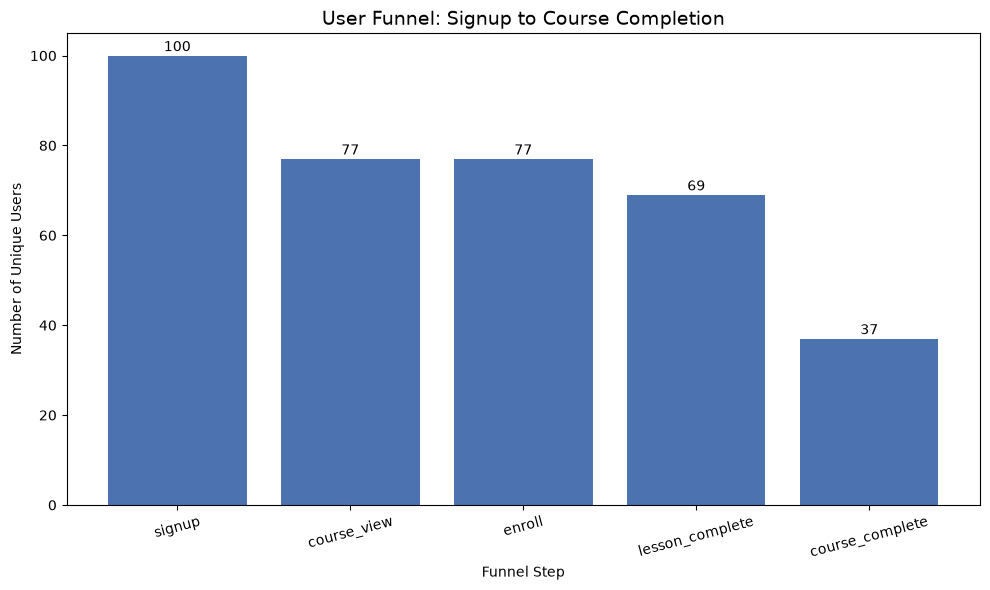

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(funnel_df['Step'], funnel_df['Unique Users'], color='#4C72B0')

plt.title('User Funnel: Signup to Course Completion', fontsize=14)
plt.xlabel('Funnel Step')
plt.ylabel('Number of Unique Users')
plt.xticks(rotation=15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, int(height), ha='center')

plt.tight_layout()
plt.show()

In [5]:
# Convert createdAt to datetime and extract signup week
users_df['createdAt'] = pd.to_datetime(users_df['createdAt'])
users_df['signup_week'] = users_df['createdAt'].dt.to_period('W').astype(str)

# Only look at students (not instructors)
students_df = users_df[users_df['role'] == 'student'].copy()

# Get all enroll events with their dates
events_df['createdAt'] = pd.to_datetime(events_df['createdAt'])
enroll_events = events_df[events_df['eventType'] == 'enroll'][['user', 'createdAt']].copy()
enroll_events['activity_week'] = enroll_events['createdAt'].dt.to_period('W').astype(str)

# Merge signup week info into enroll events
enroll_events = enroll_events.merge(
    students_df[['_id', 'signup_week']],
    left_on='user', right_on='_id', how='left'
)

# Count unique users per (signup_week, activity_week) pair
cohort_data = enroll_events.groupby(['signup_week', 'activity_week'])['user'].nunique().reset_index()
cohort_data.columns = ['Signup Week', 'Activity Week', 'Active Users']

print(cohort_data.head(20))

              Signup Week          Activity Week  Active Users
0   2026-06-01/2026-06-07  2026-06-29/2026-07-05             4
1   2026-06-01/2026-06-07  2026-07-06/2026-07-12             4
2   2026-06-01/2026-06-07  2026-07-13/2026-07-19             2
3   2026-06-01/2026-06-07  2026-07-20/2026-07-26             3
4   2026-06-01/2026-06-07  2026-07-27/2026-08-02             1
5   2026-06-01/2026-06-07  2026-08-03/2026-08-09             2
6   2026-06-01/2026-06-07  2026-08-10/2026-08-16             2
7   2026-06-01/2026-06-07  2026-08-17/2026-08-23             3
8   2026-06-01/2026-06-07  2026-08-24/2026-08-30             1
9   2026-06-08/2026-06-14  2026-07-06/2026-07-12             2
10  2026-06-08/2026-06-14  2026-07-13/2026-07-19             1
11  2026-06-08/2026-06-14  2026-08-03/2026-08-09             2
12  2026-06-08/2026-06-14  2026-08-10/2026-08-16             1
13  2026-06-08/2026-06-14  2026-08-17/2026-08-23             1
14  2026-06-15/2026-06-21  2026-06-29/2026-07-05       

In [6]:
# Create a pivot table: rows = signup week, columns = activity week, values = active users
retention_pivot = cohort_data.pivot(index='Signup Week', columns='Activity Week', values='Active Users').fillna(0)

print(retention_pivot)

Activity Week          2026-06-29/2026-07-05  2026-07-06/2026-07-12  \
Signup Week                                                           
2026-06-01/2026-06-07                    4.0                    4.0   
2026-06-08/2026-06-14                    0.0                    2.0   
2026-06-15/2026-06-21                    1.0                    1.0   
2026-06-22/2026-06-28                    1.0                    1.0   
2026-06-29/2026-07-05                    0.0                    3.0   
2026-07-06/2026-07-12                    0.0                    1.0   
2026-07-13/2026-07-19                    0.0                    2.0   
2026-07-20/2026-07-26                    0.0                    2.0   
2026-07-27/2026-08-02                    1.0                    1.0   
2026-08-03/2026-08-09                    0.0                    2.0   
2026-08-10/2026-08-16                    1.0                    2.0   
2026-08-17/2026-08-23                    4.0                    2.0   
2026-0

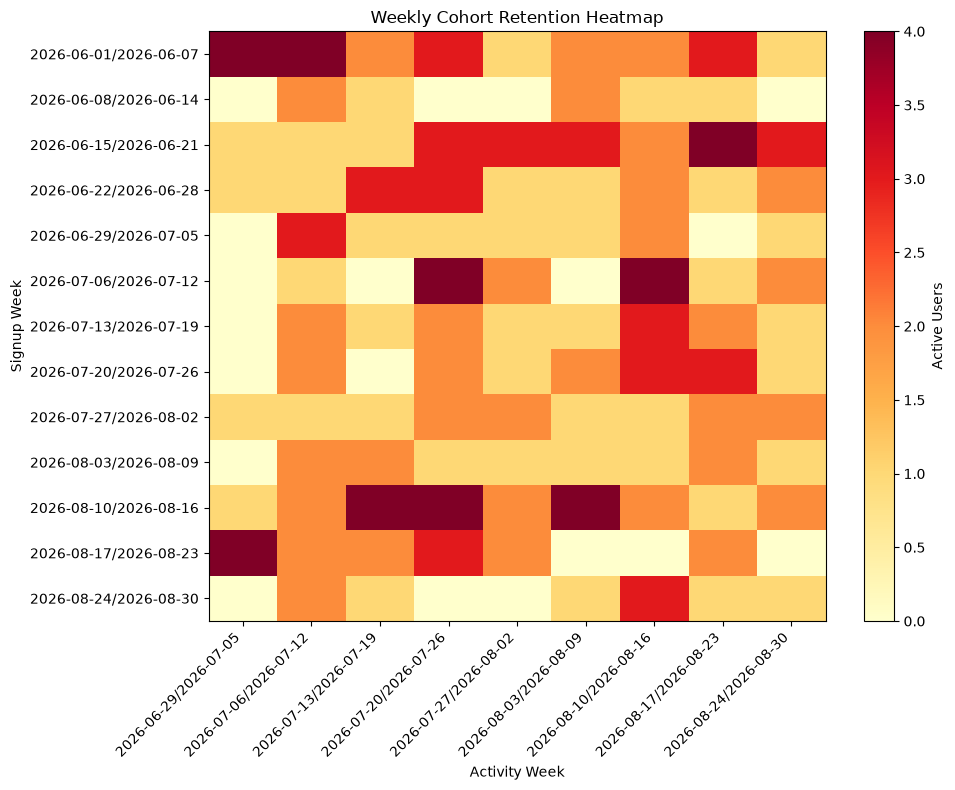

In [7]:
plt.figure(figsize=(10, 8))
plt.imshow(retention_pivot, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Active Users')
plt.title('Weekly Cohort Retention Heatmap')
plt.xlabel('Activity Week')
plt.ylabel('Signup Week')
plt.xticks(range(len(retention_pivot.columns)), retention_pivot.columns, rotation=45, ha='right')
plt.yticks(range(len(retention_pivot.index)), retention_pivot.index)
plt.tight_layout()
plt.show()

In [8]:
# Merge enrollments with course info to get category
enrollments_merged = enrollments_df.merge(
    courses_df[['_id', 'category']],
    left_on='course', right_on='_id', how='left'
)

# Calculate completion rate per category
category_stats = enrollments_merged.groupby('category').agg(
    total_enrollments=('status', 'count'),
    completed=('status', lambda x: (x == 'completed').sum())
).reset_index()

category_stats['completion_rate (%)'] = (
    category_stats['completed'] / category_stats['total_enrollments'] * 100
).round(1)

category_stats = category_stats.sort_values('completion_rate (%)', ascending=False)

print(category_stats)

       category  total_enrollments  completed  completion_rate (%)
4   Programming                 40         13                 32.5
0      Business                 33          9                 27.3
2        Design                 58         12                 20.7
3     Marketing                 54         11                 20.4
1  Data Science                 22          3                 13.6


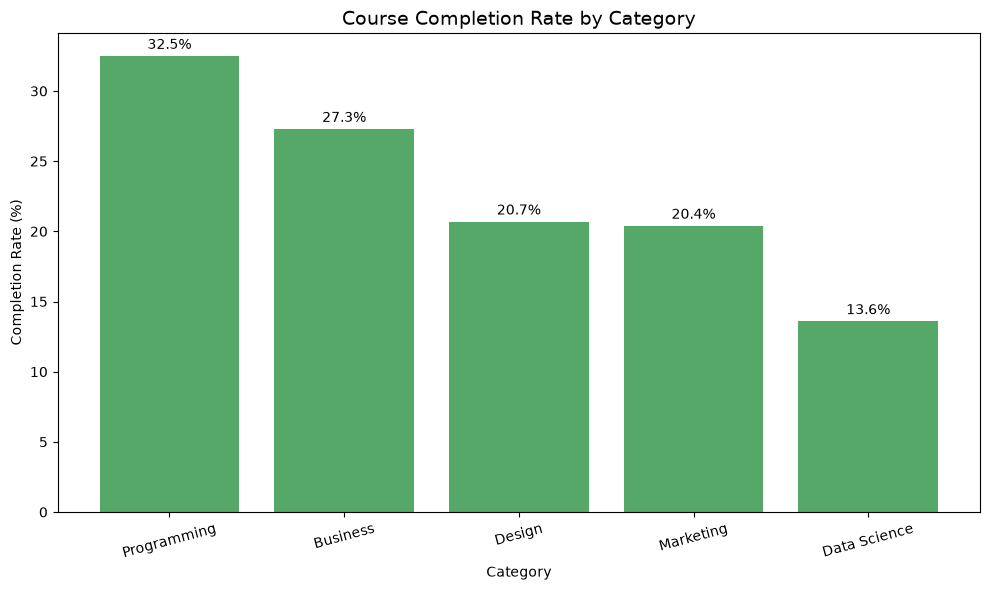

In [9]:
plt.figure(figsize=(10, 6))
bars = plt.bar(category_stats['category'], category_stats['completion_rate (%)'], color='#55A868')

plt.title('Course Completion Rate by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Completion Rate (%)')
plt.xticks(rotation=15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height}%', ha='center')

plt.tight_layout()
plt.show()